In [73]:
import pandas as pd
import numpy

import matplotlib.pyplot as plt
import seaborn

import keras
from keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score

import re

In [2]:
df = pd.read_csv("sentiment_dataset.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290458 entries, 0 to 290457
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    290458 non-null  str  
 1   label   290458 non-null  int64
 2   src     290458 non-null  str  
dtypes: int64(1), str(2)
memory usage: 178.2 MB


In [4]:
df = df[df["label"] != 0]
df["label"] = df["label"].replace(2, 0)
df.drop("src", axis=1, inplace=True)

In [5]:
df.label.value_counts()

label
0    96992
1    96877
Name: count, dtype: int64

In [6]:
df["text"] = df["text"].str.replace('\n\n', ' ', regex=False)
df["text"] = df["text"].str.replace('\n', ' ', regex=False)

In [7]:
df.reset_index(drop='index', inplace=True)

In [8]:
df

,text,label
0,отличная рубашка. на размер 46- 48 брала xxl,1
1,"куртка отличная, тёплая, но еврозима...в ней о...",1
2,"Заказ шёл меньше месяца ,заказала 11.11 по цен...",1
3,Товар не пришёл но деньги вернули,1
4,отличная майка! пришла быстро!спасибо!,1
...,...,...
193864,Как всегда вкусный и свежий.,1
193865,Обалденный!,1
193866,"Достоинства: Вкусно, лучшая паста Недостатки: ...",1
193867,"Достоинства: Увлажняет очень хорошо, и кожа ка...",1


## Tokenize

In [9]:
text = list(df["text"].values)

In [10]:
pattern = r'[а-яёА-ЯЁ]+'

seqText = []

for item in text:
    seq = re.findall(pattern, item)
    seqText.append(' '.join(seq).lower())

In [17]:
uniq = set()

for i in seqText:
    for j in i.split(" "):
        uniq.add(j)

vocab_size = len(uniq)
vocab_size

336799

In [18]:
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(seqText)
sequences = tokenizer.texts_to_sequences(seqText)
data = pad_sequences(sequences, maxlen=20)

## Data

In [24]:
X_train, X_temp, y_train, y_temp = train_test_split(data, 
                                                    df.label.values, 
                                                    train_size=0.7, 
                                                    stratify=df.label.values,
                                                    random_state=1)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp,
                                                    y_temp, 
                                                    train_size=0.5,
                                                    stratify=y_temp,
                                                    random_state=1)

## Modeling

In [70]:
model = Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=20,
        mask_zero=True
    ),

    layers.RNN(layers.SimpleRNNCell(20)),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [71]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",   
    patience=3,          
    restore_best_weights=True  
)

history = model.fit(X_train, y_train,
                    validation_data=(X_valid, y_valid),
                    epochs=100,
                    batch_size=128,
                    callbacks=[early_stop])

Epoch 1/100
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.8149 - loss: 0.4077 - val_accuracy: 0.8578 - val_loss: 0.3336
Epoch 2/100
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.9099 - loss: 0.2409 - val_accuracy: 0.8476 - val_loss: 0.3540
Epoch 3/100
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.9499 - loss: 0.1456 - val_accuracy: 0.8365 - val_loss: 0.4238
Epoch 4/100
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.9716 - loss: 0.0857 - val_accuracy: 0.8326 - val_loss: 0.5433


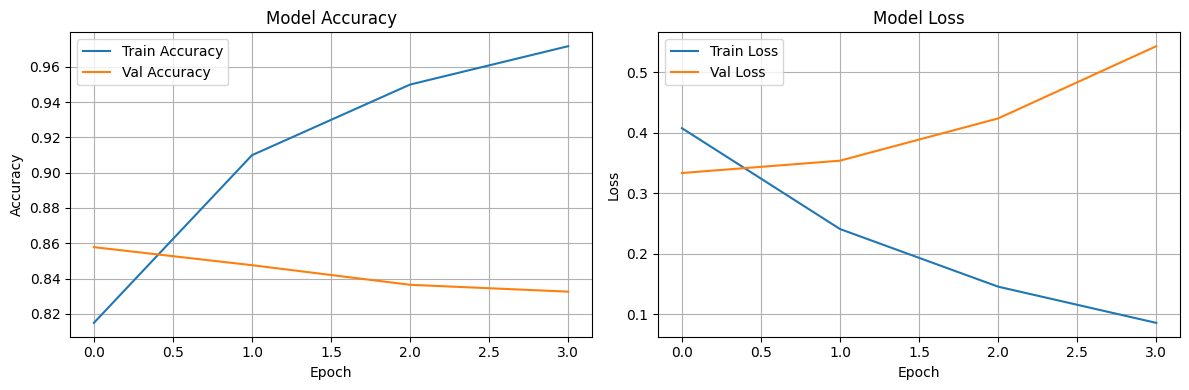

In [72]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [84]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
y_pred = y_pred.flatten()

Re = recall_score(y_test, y_pred)
Pr = precision_score(y_test, y_pred)
F1 = f1_score(y_test, y_pred)

print(f"Recall - {Re:.2f}\nPrecision - {Pr:.2f}\nF1 Score - {F1:.2f}")

909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Recall - 0.83
Precision - 0.87
F1 Score - 0.85
